*Here we are doing sentiment analysis using bitcoin tweets scrapped from the twitter. There are these data above 19M rows with some NA values. We are importing the sentiment dataset from kaggle.*

*Important steps in the sentiment analysis:*


*   *Load these data as iterator (chunk) method*
*   *Preprocessing steps*
*   *splitting the preprocessed dataset into training and testing data*
*   *Training the train data using different models and testing these models with testing data*
*   *Final evaluation and improvements*



In [ ]:
# !pip uninstall numpy -y
# !pip install numpy==1.26.4

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 97.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.36.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0

In [ ]:
# installing necessary libraries
!pip install contractions
!pip install fast-langdetect
!wget https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 789.9/789.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.1/296.1 kB 25.6 MB/s eta 0:00:00
--2026-01-26 07:05:35--  https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.35.238.71, 13.35.238.84, 13.35.238.113, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.35.238.71|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 131266198 (125M) [application/octet-stream]
Saving to: ‘lid.176.bin’

lid.176.bin         100%[===================>] 125.18M   321MB/s    in 0.4s    

2026-01-26 07:05:36 (321 MB/s) - ‘lid.176.bin’ saved [131266198/131266198]



In [ ]:
# importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import itertools
from kagglehub import KaggleDatasetAdapter
import re
import contractions
import nltk
from nltk.corpus import reuters
from nltk.corpus import stopwords
import fasttext
import os
import math
import torch
from scipy.special import softmax
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
tqdm.pandas()

In [ ]:
# necessary libray associated with vader
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
# importing and downloading necessary roberta model
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax

MODEL = 'cardiffnlp/twitter-xlm-roberta-base-sentiment'
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

In [ ]:
# !unzip /content/drive/MyDrive/btc_tweets_feb2021_july2021.zip

Archive:  /content/drive/MyDrive/btc_tweets_feb2021_july2021.zip
  inflating: btc_tweets_feb2021_july2021.csv  


In [ ]:
# Displaying the full data, ie, it increases the column width
pd.set_option('display.max_colwidth', None)

In [ ]:
iters = []
# Set the path to the file you'd like to load. Pathe is same as the file present in the kaggle
file_paths = [
    "Bitcoin_tweets.csv",
    "Bitcoin_tweets_dataset_2.csv"
]
REQUIRED_COLS = ['date', 'text', 'user_followers']

for file_path in ["Bitcoin_tweets.csv", "Bitcoin_tweets_dataset_2.csv"]:
  # Load the dataset from kaggle using iterator method (loading 500,000 rows at once)
  # all the bad lines such as unclosed quotes, invalid charcters etc are skipped or removed
  it = kagglehub.dataset_load(
      KaggleDatasetAdapter.PANDAS,
      "kaushiksuresh147/bitcoin-tweets",
      file_path,
      pandas_kwargs={
          "chunksize": 500_000,
          "engine": "python",
          "on_bad_lines": "skip",
          "usecols": REQUIRED_COLS
      }
    )
  iters.append(it)

  local_it = pd.read_csv(
    "/content/btc_tweets_feb2021_july2021.csv",
    chunksize=500_000,
    engine="python",
    on_bad_lines="skip",
    usecols=REQUIRED_COLS
)

iters.append(local_it)


df = itertools.chain(*iters)
chunk = next(df)
chunk.head()

Using Colab cache for faster access to the 'bitcoin-tweets' dataset.


100%|██████████| 24.5M/24.5M [00:02<00:00, 10.4MB/s]

Extracting zip of Bitcoin_tweets_dataset_2.csv...


,user_followers,date,text
0,8534.0,2021-02-10 23:59:04,Blue Ridge Bank shares halted by NYSE after #bitcoin ATM announcement https://t.co/xaaZmaJKiV @MyBlueRidgeBank… https://t.co/sgBxMkP1SI
1,6769.0,2021-02-10 23:58:48,"😎 Today, that's this #Thursday, we will do a ""🎬 Take 2"" with our friend @LeoWandersleb, #Btc #wallet #security expe… https://t.co/go6aDgRml5"
2,128.0,2021-02-10 23:54:48,"Guys evening, I have read this article about BTC and would like to share with you all - https://t.co/QxCZgmuy3B… https://t.co/o6wn7ppkVY"
3,625.0,2021-02-10 23:54:33,$BTC A big chance in a billion! Price: \4872644.0 (2021/02/11 08:51) #Bitcoin #FX #BTC #crypto
4,1249.0,2021-02-10 23:54:06,"This network is secured by 9 508 nodes as of today. Soon, the biggest bears will recognise: #BTC in too big to fail… https://t.co/1XovDA8rKw"


In [ ]:
chunk.shape  # each chunk as 500,000 rows

(500000, 3)

In [ ]:
# # we have a chunk of data (500,000 each of around 4M rows)
# for i, chunk in enumerate(df):
#   print(f"Chunk {i}")
#   print(f"Data size {chunk.shape}")
#   display(chunk.head())

*Now we are starting the different preprocessing steps:*


1.   *convert Date (string datatype) column as datetime type*  
2.   *removing null values in the date time column*
3.   *sort using Date*
4.   *preprocessing the text column using the regular expression methods*
5.   *Now converting the preprocessed text data into sentiment scores - positive, neutral, negative*
6.   *Now comparing and evaluating the predicted values with original sentiment of each row*



In [ ]:
def date_preprocess(data):
  # Convert to datetime type, invalid ones → NaT (Not a Time)
  data['date'] = pd.to_datetime(data['date'], errors='coerce')
  # Remove rows with invalid date, ie, removing NaT values
  data = data.dropna(subset=['date'])
  return data

*Total is above 19M rows, after removing the corrupted csv lines we got 17,952,946 rows. Then by using date_preprocess() function we got 17,952,917 rows (29 rows removed).*

In [ ]:
SPAM_KEYWORDS = {
    "GIVEAWAY": [
        "giveaway", "airdrop", "free crypto", "free bitcoin", "free btc",
        "free eth", "free tokens", "free coins", "claim now", "free money",
        "win crypto", "prize", "contest", "drop your wallet", "enter to win",
        "winner announced", "winner in", "tag 3 friends", "tag friends",
        "must follow", "drop your btc", "drop your eth"
    ],
    "PROMOTIONAL": [
        "click here", "link in bio", "check out", "visit our",
        "sign up now", "register now", "download now", "promo code",
        "discount code", "referral code", "affiliate", "sponsored",
        "dm for access", "dm to join", "dm me", "check pinned"
    ],
    "ENGAGEMENT": [
        "retweet and follow", "rt and follow", "like and rt",
        "follow and rt", "tag friends", "follow me", "follow back", "f4f",
        "rt to enter", "follow + rt", "must follow"
    ],
    "PUMP_DUMP": [
        "100x", "1000x", "moon", "to the moon", "buy now",
        "pump incoming", "whale alert", "hidden gem", "moonshot",
        "next bitcoin", "ground floor"
    ],
    "GUARANTEED_RETURNS": [
        "guaranteed profit", "guaranteed returns", "100% profit",
        "no risk", "risk free", "double your", "passive income", "easy money",
        "guaranteed"
    ],
    "URGENCY": [
        "urgent buy", "hurry up", "act now", "don't miss",
        "ending soon", "expires soon", "limited time", "today only",
        "in next 48 hours", "within 1 hour", "closes tonight",
        "last 2 hours", "final warning", "last chance", "ends tonight",
        "limited spots"
    ],
    "MLM_SCHEME": [
        "investment opportunity", "business opportunity",
        "financial independence", "mlm", "pyramid", "ponzi", "refer and earn"
    ],
    "PHISHING": [
        "verify your wallet", "confirm your wallet",
        "account suspended", "seed phrase", "private key",
        "wallet flagged", "security alert", "unauthorized access"
    ],
    "TRADING_SIGNAL": [
        "trading signal", "buy signal", "vip signal",
        "premium signal", "free signal", "never lose",
        "win rate", "vip group"
    ],
    "ICO_PRESALE": [
        "presale live", "presale now", "ico live",
        "token launch", "launching soon", "token sale",
        "presale ending", "token sale closes"
    ],
    "BOT": [
        "trading bot", "auto trade", "automated trading",
        "profit bot", "increase balance", "autopilot"
    ],
    "RECOVERY_SCAM": [
        "recovery service", "recover funds",
        "hacked wallet", "fund recovery"
    ],
    "CELEBRITY": [
        "elon musk", "elon said", "musk announced",
        "as seen on cnn", "as seen on bbc", "vitalik buterin",
        "vitalik", "buterin", "cz binance", "michael saylor"
    ],
    "LOW_QUALITY": [
        "gm crypto", "gn crypto", "wagmi", "ngmi",
        "wen moon", "wen lambo"
    ],
    "EMOJI_SPAM": [],  # Handled separately
    "NFT_SPAM": [
        "nft giveaway", "nft airdrop",
        "free nft", "mint now", "nft drop", "free mint"
    ]
}

In [ ]:
SPAM_WEIGHTS_NEW = {
    "GIVEAWAY": 2.8,           # Increased from 2.5
    "PROMOTIONAL": 2.0,
    "ENGAGEMENT": 1.8,         # Increased from 1.5
    "PUMP_DUMP": 3.5,
    "GUARANTEED_RETURNS": 5.0,
    "URGENCY": 2.8,            # Increased from 2.5
    "MLM_SCHEME": 4.5,
    "PHISHING": 5.0,
    "TRADING_SIGNAL": 4.0,
    "ICO_PRESALE": 3.0,
    "BOT": 4.0,
    "RECOVERY_SCAM": 5.0,
    "CELEBRITY": 1.5,          # Increased from 1.0
    "LOW_QUALITY": 0.5,
    "EMOJI_SPAM": 1.8,         # Increased from 1.5
    "NFT_SPAM": 3.0
}

EMOJIS = ["🚀", "🔥", "💎", "🌙", "🛑", "💰", "⭐", "📢", "⚡", "🎁", "⚠️", "🔴", "🐋", "🖼️", "🎨", "🎯", "🔮"]

ENGAGEMENT_PAIRS = [
    ("follow", "rt"),
    ("rt", "follow"),
    ("like", "rt"),
    ("retweet", "follow"),
]

In [ ]:
def count_emojis(text):
    # Count emojis with bonus for repeated patterns
    emoji_pattern = r'([🚀🔥💎🌙🛑💰⭐📢⚡🎁⚠️🔴🐋🖼️🎨🎯🔮])\1{2,}'
    repeated = len(re.findall(emoji_pattern, text))
    total = sum(text.count(e) for e in EMOJIS)
    return total + (repeated * 2)

def engagement_hit(text):
    # Check for engagement bait patterns
    return any(all(w in text for w in pair) for pair in ENGAGEMENT_PAIRS)

def numeric_giveaway(text):
    # Detect giveaways with specific amounts
    return bool(re.search(r'(win|giveaway|giving away)\s+\d+\s*(btc|eth|usdt)', text, re.IGNORECASE))

def doubling_scam(text):
    # Detect 'send X get 2X back' scams
    return bool(re.search(r'send\s+[\d.]+.*get\s+[\d.]+.*back', text, re.IGNORECASE))

def has_suspicious_url(text):
    # Check for suspicious URLs
    suspicious = [
        'bit.ly', 'tinyurl', 'goo.gl',
        '.scam', '-fake', 'fake.com',
        'opensea-', 'metamask-', 'binance-', 'coinbase-',
        'claim-', 'verify-', 'secure-'
    ]
    return any(pattern in text for pattern in suspicious)

def is_spam(text, threshold=3.5):  # Lowered from 4.0
    """
    Detect spam content with multi-signal scoring

    Args:
        text: Input text to analyze
        threshold: Score threshold for spam classification (default: 3.5)

    Returns:
        tuple: (is_spam: bool, score: float)
    """
    text_lower = text.lower()
    score = 0.0
    matched_categories = 0

    # URL check - counts as independent signal
    if has_suspicious_url(text_lower):
        score += 3.0
        matched_categories += 1

    # Doubling scam check - very suspicious
    if doubling_scam(text_lower):
        score += 4.0
        matched_categories += 1

    # Process each category
    for category, keywords in SPAM_KEYWORDS.items():
        hits = 0

        if category == "EMOJI_SPAM":
            # Special handling for emojis
            emoji_count = count_emojis(text)
            if emoji_count >= 3:
                hits = emoji_count
        else:
            # Normal keyword matching
            for kw in keywords:
                hits += text_lower.count(kw)

        # Category-specific semantic boosts
        if category == "GIVEAWAY":
            if numeric_giveaway(text_lower):
                hits += 2  # Increased from 1

        if category == "ENGAGEMENT":
            if engagement_hit(text_lower):
                hits += 2  # Increased from 1

        # Add to score if category matched
        if hits > 0:
            matched_categories += 1
            score += SPAM_WEIGHTS_NEW[category] * math.log1p(hits)

    # Multi-signal requirement with severity exceptions
    if matched_categories == 1 and score < 4.5:
        return False, score
    elif matched_categories < 2 and score < 3.5:
        return False, score

    return score >= threshold, score

In [ ]:
# finding the no. of hashtags in the tweets
def count_hashtags(text):
    return len(re.findall(r"#\w+", text))

In [ ]:
def filtering_pipeline(text, followers, threshold=3.5):
  # converting followers count to float and null value followers change to 0
  try:
      followers = float(followers)
  except (TypeError, ValueError):
      followers = 0

  # tweets from account with fewer than 10 followers were removed
  if followers < 10:
      return True

  # filtering tweets with excessive hashtags (>5)
  if count_hashtags(text) > 5:
    return True

  # calling the is_spam() function to check whether a tweet is spam or not
  is_spam_content, score = is_spam(text, threshold)
  if is_spam_content:
      return True

  return False

*Now we are doing the following text preprocessing for extracting a good sentiment score from the crypto.*

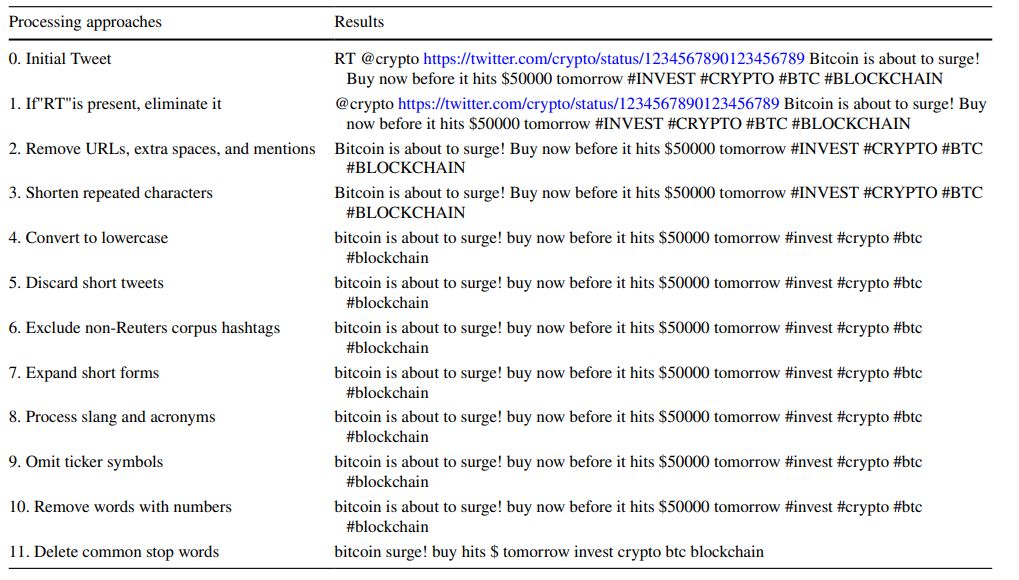

In [ ]:
CRYPTO_HASHTAG_VOCAB = {
    # Coins / assets
    "bitcoin", "btc", "ethereum", "eth", "bnb", "solana", "sol",
    "xrp", "dogecoin", "doge", "cardano", "ada",

    # Market sentiment
    "bullish", "bearish", "bullrun", "bearmarket",
    "moon", "to_the_moon", "pump", "dump",
    "breakout", "breakdown", "rally", "crash",

    # Price & metrics
    "ath", "atl", "high", "low",
    "resistance", "support",
    "volume", "volatility", "dominance",

    # Trading actions
    "buy", "sell", "hold", "hodl",
    "long", "short", "leverage",
    "entry", "exit", "takeprofit", "stoploss",

    # News & events
    "etf", "halving", "airdrop",
    "listing", "delisting",
    "regulation", "sec", "fed",

    # Slang / emotions
    "fomo", "fud", "rekt", "ngmi", "wagmi",
    "lfg", "gm", "gn"
}


In [ ]:
# download necessary hastag words (reuters) from nltk
nltk.download('reuters')

# Build Reuters English vocabulary which will use to expand words
REUTERS_VOCAB = set(word.lower() for word in reuters.words())
# Addin some crypto related hashtag wors to the REUTERS_VOCAB
REUTERS_VOCAB.update(CRYPTO_HASHTAG_VOCAB)

[nltk_data] Downloading package reuters to /root/nltk_data...


In [ ]:
CRYPTO_SLANG_ACRONYM_MAP = {
    # Slang terms
    "hodl": "hold",
    "fomo": "fear of missing out",
    "fud": "fear uncertainty doubt",
    "rekt": "financially ruined",
    "moon": "price increase rapidly",
    "dump": "sharp price fall",
    "pump": "artificial price increase",
    "bagholder": "investor holding losses",
    "whale": "large investor",
    "bearish": "expecting price fall",
    "bullish": "expecting price rise",
    "ath": "all time high",
    "atl": "all time low",

    # Acronyms
    "btd": "buy the dip",
    "dyor": "do your own research",
    "ngmi": "not going to make it",
    "wagmi": "we are going to make it",
    "lmao": "laughing my ass off",
    "imo": "in my opinion",
    "idk": "i do not know"
}


In [ ]:
# download stopword sets from nltk
nltk.download('stopwords')

# stop words are words that less or no contribute to the sentiments such as the, to, an, and, etc
STOP_WORDS = set(stopwords.words('english'))
# Preserve negations which has a large contributions to sentiments
NEGATIONS = {"not", "no", "nor", "never", "don't", "dont", "can't", "won't", "n't"}
STOP_WORDS = STOP_WORDS - NEGATIONS

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# text or tweets are preprocessing using regular expressiond (re -> python library)
def text_preprocessing(text):
  # removing retweets like: "RT @user: text"
  text = re.sub(r'(?i)^\s*rt\s+@?\w+:?', '', text)

  # first removing the urls from the tweets
  text = re.sub(r'https?://\S+|www\.\S+', '', text) # \S -> all characters including nums and special symbls until a space or newline chars

  # removing the mentions, (?<!\w)@ -> checking the char immediately before @ is a space not a letter, num or any other char
  text = re.sub(r'(?<!\w)@[a-zA-Z0-9_]+', '', text)

  # removing extra spaces and newline characters into a single space
  text = re.sub(r'\s+', ' ', text)
  text = text.strip() # removing leading and trailing spaces

  # shorten repeated characters, nooooo -> noo
  text = re.sub(r'(.)\1{3,}', r'\1\1\1', text)

  # lowercasing all the characters in the text excluding hashtags
  text = text.lower()

  # removing short tweets, length of words < 4
  if len(text.split()) < 4:
    return None

  # Process hashtags using Reuters dictionary
  def handle_hashtag(match):
      word = match.group(1)
      if word in REUTERS_VOCAB:
          return word # removing the '#' symbols, keeping the words only
      else:
          return '' # remove entire hashtag
  text = re.sub(r'#([a-z]+)', handle_hashtag, text) # calling the handle_hastag function where each hastag as parameter implicitly passed

  # contractions is a library contains dictionary of English contractions, eg: "you're" -> "you are", "they've" -> "they have"
  def expand_contractions(text):
    return contractions.fix(text)
  text = expand_contractions(text) # expanding the short forms using expand_contractions function

  # expanding the slang or acronyms to their expanded forms, fomo -> fear of missing out, using the CRYPTO_SLANG_ACRONYM_MAP created above
  def expand_crypto_slang_acronyms(text):
    for term, expand in CRYPTO_SLANG_ACRONYM_MAP.items():
      pattern = rf'\b{term}\b' # r -> raw string using in regex that not treating \b as blackslashes instead using it has regex boundary (\b...\b), only take single 'ath' not the 'ath' in word 'bath'
                               # f -> formated string used to replace the 'term' with appropriate word
      text = re.sub(pattern, expand, text)
    return text
  text = expand_crypto_slang_acronyms(text)

  # removing the ticker symbols such as $btc, $ETH, etc
  text = re.sub(r'\$[A-Za-z]{2,}', '', text)
  # removing the '$' for next step
  text = re.sub(r'\$', '', text)

  # removing the words with nums
  text = re.sub(r'\b\w*\d+\w*\b', '', text, flags=re.UNICODE)

  # remove punctuation and excessive special characters
  text = re.sub(r"[!\"#$%&'()*+,\-./:;<=>?@\[\]^_`{|}~]+", " ", text)
  text = re.sub(r"\s+", " ", text).strip()

  # removing the stop words
  def removing_stopwords(text):
    text = text.split() # splitting list of tokens -> ['bitcoin', 'is', 'high']
    text = [token for token in text if token not in STOP_WORDS] # only take the word that is not a stop word
    return ' '.join(text)
  text = removing_stopwords(text)

  return text

In [ ]:
# test case 1 - preprocessing a tweet using the above function:
print(text_preprocessing("@crypto https://twitter.com/crypto/status/1234567890123456789 Bitcoin is price going up price going up price going up about to surge! Buy now before it hits $50000 $50000 tomorrow #INVEST #CRYPTO #BTC #BLOCKCHAIN"))

bitcoin price going price going price going surge buy hits tomorrow invest btc


In [ ]:
# test case 2:
print(text_preprocessing("🚀🚀🚀 #Bitcoin just hit $BTC $ETH $65000!!! \nCheck this out: https://example.com/article\n@elonmusk you're sooo right about crypto FOMO!! \nIt's over 30+ years since we've seen this!! \nThe price increased by 150% on 12/24/2024 at 14:30:00\nNooooooo way this is happeningggg 😂\nATH ATH ATH rocket rocket rocket\n$DOGE to the mooooooon!!!\nabc123 test456 #FakeNews #Ethereum\nThey've been HODLing since -5000 dropped"))

🚀🚀🚀 bitcoin hit check sooo right crypto fear missing years since seen price increased nooo way happeninggg 😂 time high time high time high rocket rocket rocket mooon ethereum hodling since dropped


*We have the english language tweets as well as non-english tweets. We trying to fetch sentimentals from both of them. The above preprocessing steps can be applied only to the english tweets. We use a minimal preprocess steps for non english tweets.*

In [ ]:
# Minimal cleaning for non-English tweets
def minimal_text_preprocess(text):
  text = re.sub(r'https?://\S+|www\.\S+', '', text) # remove urls
  text = re.sub(r'@\w+', '', text) # remove mentions
  text= re.sub(r'\s+', ' ', text).strip() # normalize spaces
  text = text if len(text.split()) >= 3 else None # take the texts with minimum 3 words in it
  return text

*We are preprocessing both english and non-english texts using the above preprocessing methods. we using a language detector to detect whether a language is english or non-english.*

In [ ]:
FASTTEXT_MODEL_PATH = "lid.176.bin"
ft_lang_model = fasttext.load_model(FASTTEXT_MODEL_PATH)

def fasttext_detect(text, min_prob=0.7):
    if not isinstance(text, str):
        return "err"

    # tweets with multiple line is coverted to sigle line for covering the full path of the text for lang detection
    text = text.replace("\n", " ").strip()

    # short texts or tweets which are also taken and passes to english text processing pipeline for modelling it with VADER
    if len(text) < 10 or len(text.split()) < 3:
        return "unknown"

    # FastText predicts 2 lists, one for language label and other is its confidence score or probability
    try:
        labels, probs = ft_lang_model.predict(text, k=1) # k=1 means it gives the top one list (only one for both label and prob)
    except Exception:
        return "err" # empty inputs or malformed (non-string) inputs are written as 'err'

    # sometimes it return empty list for label or probs, which also marked as 'unknown'
    if not labels or not probs:
        return "err"

    # returning label format: __label__en, where en -> english
    lang = labels[0].replace("__label__", "") # we only extracting the 'en' part
    prob = probs[0]

    # probability is less than a threshold, it will also return as 'unknown'
    if prob < min_prob:
        return "unknown"

    return lang


*Mixed scripts, only emoji or too short tweets are marked as 'unknown', dropping "unknown" tweets hurts sentiment analysis. So passed it to VADER model which gives a good sentimental score by analyzing it. VADER is specifically designed for short texts, social media, emojis, slang, etc.*

In [ ]:
# Preprocess a DataFrame chunk. Detect language, apply English preprocessing for English tweets, minimal cleaning for non-English.
def preprocess_multilang_tweets_fasttext(chunk, col='text'):
    # storing the preprocessed texts one by one, final list length = number of rows in the chunk
    processed_texts = []

    for text in tqdm(chunk[col], total=len(chunk), desc="Preprocessing tweets", leave=False):
        # checking whether each text row in the chunks of dataframe is string or not
        if not isinstance(text, str):
            processed_texts.append(None) # if not str, we append None value to the processed_texts list instead of the original one
            continue

        # detect language using FastText
        lang = fasttext_detect(text)

        # if lang is english or unknown (mostly for VADER) we used text_preprocessing()
        if lang == "en" or lang == "unknown":
            processed_texts.append(text_preprocessing(text))
        elif lang == "err":
            processed_texts.append(None)
        # other languages are passed through miniman_text_preprocess()
        else:
            processed_texts.append(minimal_text_preprocess(text))

        if i % 50_000 == 0 and i > 0:
            print(f" processed {i} rows")

    # now the processed tweets are append with the original chunks of df
    chunk['processed_text'] = processed_texts
    return chunk

*Implementing VADER*

In [ ]:
# Crypto-specific sentiment terms
CRYPTO_LEXICON = {
    "bullish": 3.2,
    "bearish": -3.1,
    "hodl": 2.4,
    "fomo": -1.9,
    "ath": 3.4,
    "moon": 3.5,
    "pump": 2.8,
    "dump": -2.9,
    "rekt": -3.6,
    "rugpull": -3.9,
    "scam": -4.0,
    "crash": -3.5,
    "breakout": 3.0,
    "accumulate": 2.1,
    "selloff": -2.6,
}

# Loughran–McDonald inspired financial terms
FINANCIAL_LEXICON = {
    "profit": 2.7,
    "profits": 2.8,
    "growth": 2.4,
    "loss": -2.7,
    "losses": -2.9,
    "decline": -2.4,
    "risk": -1.8,
    "uncertainty": -1.7,
    "bankruptcy": -3.5,
    "fraud": -4.0,
    "regulation": -1.6,
    "ban": -3.0,
    "lawsuit": -3.1,
}

In [ ]:
def vader_pipeline(chunk):
  # creating a object
  sia = SentimentIntensityAnalyzer()

  # Merge custom lexicons
  CUSTOM_LEXICON = {}
  CUSTOM_LEXICON.update(CRYPTO_LEXICON)
  CUSTOM_LEXICON.update(FINANCIAL_LEXICON)
  # Inject into VADER
  sia.lexicon.update(CUSTOM_LEXICON)

  # run the polarity_score on the entire dataset and creating a score df containing the sentimental scores
  scores = chunk['processed_text'].progress_apply(sia.polarity_scores)
  scores_df = pd.DataFrame(list(scores))

  # merging each tweet with its sentiment score
  scores_df = scores_df.reset_index(drop=True)
  chunk = chunk.reset_index(drop=True)
  chunk = pd.concat([chunk, scores_df], axis=1)

  return chunk

*Implementing RoBERTa*

In [ ]:
def roberta_pipeline(chunk, batch_size=32, device=None):
    # Auto-detect device if not provided
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'

    model.eval().to(device)
    texts = chunk['processed_text'].tolist()

    probs_all = []

    with torch.no_grad():
        for i in tqdm(
            range(0, len(texts), batch_size),
            desc="RoBERTa inference",
            leave=False
        ):
            enc = tokenizer(
                texts[i:i+batch_size],
                padding=True,
                truncation=True,
                max_length=128,
                return_tensors='pt'
            ).to(device)

            logits = model(**enc).logits
            probs_all.append(softmax(logits.cpu().numpy(), axis=1))

    scores = np.vstack(probs_all)

    chunk[['roberta_neg','roberta_neu','roberta_pos']] = scores

    # class index
    labels = np.argmax(scores, axis=1)

    # max probability = intensity
    intensity = np.max(scores, axis=1)

    # signed sentiment score (paper-style)
    roberta_score = np.select(
        [labels == 2, labels == 0],
        [intensity, -intensity],
        default=0.0   # neutral
    )

    chunk['roberta_score'] = roberta_score


    return chunk

*Now we are implementing all the above functions defined above for getting the sentimental scores.*



1.   *date_preprocess()*
2.   *spam_and_bot_filtering()*
3.   *preprocess_multilang_tweets_using_above_steps()*

        *   *text_preprocessing()*
        *   *minimal_text_preprocess()*
4.   *implementing_vader()*
5.   *implementing_roberta()*







In [ ]:
OUTPUT_CSV = "final_sentiment_timeseries.csv"
# remove file if it already exists (fresh run)
if os.path.exists(OUTPUT_CSV):
    os.remove(OUTPUT_CSV)

for i, chunk in enumerate(df):

      print(f"Chunk {i} start: {chunk.shape}")

      # date preprocessing
      chunk = date_preprocess(chunk)

      # applying the spam filtering function and filter the tweets
      chunk['is_spam'] = chunk.apply(lambda x: filtering_pipeline(x['text'], x['user_followers']), axis=1)

      # only non-spam tweets stored, others are removed
      chunk = chunk[chunk['is_spam'] == False]

      # text preprocessing (language-aware)
      chunk = preprocess_multilang_tweets_fasttext(chunk)

      # dropping null value rows
      chunk = chunk.dropna(subset=['processed_text'])

      print(f"Chunk {i}")
      print(f"Data size {chunk.shape}")

      # vader sentiment analysis
      chunk = vader_pipeline(chunk)

      # roberta sentiment analysis
      chunk = roberta_pipeline(chunk)

       # Keep ONLY required columns
      final_chunk = chunk[[
          'date',
          'text',
          'compound',          # VADER compound
          'roberta_score'      # RoBERTa score
      ]].copy()

      # Optional: sort by time inside chunk
      final_chunk = final_chunk.sort_values('date')

      # Append to CSV (no chunk info stored)
      final_chunk.to_csv(
          OUTPUT_CSV,
          mode='a',
          header=not os.path.exists(OUTPUT_CSV),
          index=False
      )

      display(chunk.sample(10))

Chunk 0 start: (500000, 3)


/tmp/ipython-input-2697094180.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunk['is_spam'] = chunk.apply(lambda x: filtering_pipeline(x['text'], x['user_followers']), axis=1)


Chunk 0
Data size (289351, 5)


100%|██████████| 289351/289351 [01:25<00:00, 3379.31it/s]


,user_followers,date,text,is_spam,processed_text,neg,neu,pos,compound,roberta_neg,roberta_neu,roberta_pos,roberta_score
155037,24211.0,2021-08-08 14:26:46,Today we celebrate the first annual (or maybe centurial) #Bitcoin Infinity Day! https://t.co/5N4bhDwYj5,False,today celebrate first annual maybe centurial bitcoin infinity day,0.000,0.684,0.316,0.5719,0.147862,0.506892,0.345246,0.000000
172794,31182.0,2021-08-08 14:42:30,#Btc Not expecting that hard drop but lets see https://t.co/L9UVpmKOwQ,False,btc not expecting hard drop let us see,0.000,0.659,0.341,0.2755,0.297563,0.597030,0.105407,0.000000
70153,291.0,2021-07-30 11:57:02,In crypto stick with tokenomics &amp; economic value creation.\n$CEL #Bitcoin $ETH $MATIC $BNB $OKB $HOPE\n@CelsiusNetwork \n@FinanceFirebird \n@0xPolygon,False,crypto stick tokenomics amp economic value creation bitcoin,0.000,0.571,0.429,0.5423,0.083065,0.714249,0.202686,0.000000
19175,335.0,2021-07-19 12:10:11,#Bitcoin will likely shoot up if we get great regulatory news tomorrow,False,bitcoin likely shoot get great regulatory news tomorrow,0.192,0.480,0.328,0.4019,0.057117,0.313631,0.629251,0.629251
275613,17.0,2021-08-16 13:13:50,"#DCA (dollar cost average) into #Bitcoin, $ETH, $ADA, $DOT, $Matic, $Link, @CelsiusNetwork and you'll look back and thank yourself #Crypto",False,dca dollar cost average bitcoin look back thank,0.000,0.737,0.263,0.3612,0.176647,0.738467,0.084886,0.000000
243945,1566.0,2021-08-18 15:34:38,"#bitcoin (and shitcoins) are obviously just used for speculation and rainforest burning, right? \n\nThis is obviously incorrect! Most countries on this list share something: capital controls, high inflation, little economic opportunity.\n\nBitcoin fixes this. https://t.co/F2WgRLvQUh",False,bitcoin shitcoins obviously used speculation rainforest burning right obviously incorrect countries list share something capital controls high inflation little economic opportunity bitcoin fixes,0.000,0.816,0.184,0.5750,0.678049,0.257070,0.064881,-0.678049
102844,262.0,2021-07-27 12:42:23,"the bomb is occurring, as mentioned. 😎📈🐂 #btc #bitcoin #alt \n\n(he was at 37k when I said it) ✅ https://t.co/cmKePFnWZO",False,bomb occurring mentioned 😎📈🐂 btc bitcoin said ✅,0.348,0.652,0.000,-0.4939,0.150878,0.565042,0.284081,0.000000
283258,272.0,2021-08-15 22:17:14,This is why you need to have #Bitcoin https://t.co/LpOVgURzNi,False,need bitcoin,0.000,1.000,0.000,0.0000,0.252848,0.641875,0.105277,0.000000
39452,17.0,2021-07-18 04:40:01,Just signed at @cakedefi I did my research and excited to join. Please use my referral link so we both earn more https://t.co/VIfLdemQ27 #Cakedefi #Bitcoin #Ethereum,False,signed research excited join please use referral link earn bitcoin ethereum,0.000,0.537,0.463,0.7096,0.033320,0.729535,0.237146,0.000000
171173,438.0,2021-08-08 23:28:59,#BTC 🚀PUMP GOLD DUMP COMING✅ https://t.co/KX1Jh0X7zL,False,btc 🚀artificial price increase gold sharp price fall coming✅,0.000,0.777,0.223,0.3182,0.079442,0.703546,0.217012,0.000000


...

,user_followers,date,text,is_spam,processed_text,neg,neu,pos,compound,roberta_neg,roberta_neu,roberta_pos,roberta_score
37114,1163.0,2023-03-01 00:49:08,"$XRP is moving down from 0.375, Dump It📉 #btc $BTC",False,moving sharp price fall it📉 btc,0.000,1.000,0.000,0.0000,0.292920,0.498949,0.208131,0.000000
29228,13.0,2023-02-27 15:37:29,#Bitcoin is currently trading at $23689.22,False,bitcoin currently trading,0.000,1.000,0.000,0.0000,0.147365,0.715530,0.137105,0.000000
83993,11702.0,2023-03-02 20:17:20,🔥 looking for a long trade.❓ Check the post https://t.co/MpGwraxX0D #bitcoin @tradingview #crypto $btc #btc,False,🔥 looking long trade ❓ check post bitcoin btc,0.000,1.000,0.000,0.0000,0.054617,0.857149,0.088234,0.000000
89763,76.0,2023-03-02 10:49:03,"“We live in a world that encourages debt” \n\nDebt ➡️ Short term thinking ➡️ Instant gratification \n\nRhys explains the issues with living in a debt-based system and, crucially, why we say don’t be too hard on yourself in our free course!\n\n#bitcoin #bitcoinpodcast #podcast https://t.co/IpFgIyPMv9",False,“we live world encourages debt” debt ➡️ short term thinking ➡️ instant gratification rhys explains issues living debt based system crucially say not hard free course bitcoin,0.217,0.592,0.191,-0.2278,0.285251,0.509457,0.205292,0.000000
63468,19360.0,2023-03-04 12:14:03,"Tether Partners Used Fraudulent Documents to Give Company Access to Bank Accounts, Says Report : Stablecoin issuer Tether faces allegations by the Wall Street Journal that it accessed bank accounts through shell companies and… https://t.co/28rD7PqZKJ #Bitcoin #Crypto #Nft https://t.co/Q9tAhk7UTo",False,tether partners used fraudulent documents give company access bank accounts says report stablecoin issuer tether faces allegations wall street journal accessed bank accounts companies and… bitcoin,0.113,0.887,0.000,-0.4939,0.737493,0.230987,0.031520,-0.737493
26674,88.0,2023-02-27 19:21:51,Wondering if #KatieHobbs has turned herself in or has been arrested yet.??? This Sinaloa cartel is A massive crime(s). #bitcoin #FauciFiles https://t.co/6ZnQgihAv2,False,wondering turned arrested yet sinaloa cartel massive crime bitcoin,0.485,0.515,0.000,-0.7650,0.769792,0.202648,0.027559,-0.769792
20401,47770.0,2023-02-28 09:56:10,"Good Morning ☕️\n\n#Bitcoin $Btc \n\nLooks ready, send it! https://t.co/vrOD4TalKk",False,good morning ☕️ bitcoin looks ready send,0.000,0.481,0.519,0.6597,0.041763,0.317248,0.640989,0.640989
72536,466.0,2023-03-03 16:20:39,"#BTC at crucial support: Daily MA55, upper VWAP &amp; neckline. This better hold, otherwise we might revisit 19K. #Bitcoin #Crypto #Ethereum #ETH https://t.co/Vl4aLiAAj5",False,btc crucial support daily upper vwap amp neckline better hold otherwise might revisit bitcoin ethereum eth,0.000,0.714,0.286,0.6808,0.249171,0.518895,0.231934,0.000000
36390,23.0,2023-03-01 05:20:58,@ChainDustry Happy new month team. \n#March\n#Btc\n#Crypto,False,happy new month team march btc,0.000,0.575,0.425,0.5719,0.072088,0.304434,0.623478,0.623478
81259,2457.0,2023-03-03 01:47:22,2017 #btc energy FUD\n2021 more energy FUD\n2023--&gt; even more energy FUD\n\nsee the pattern?\n\nPaid shills year after year but tick tock next block continues uninterrupted\n\n#Bitcoin wins\n\nhttps://t.co/RrOAuajOoZ,False,btc energy fear uncertainty doubt energy fear uncertainty doubt gt even energy fear uncertainty doubt see pattern paid shills year year tick tock next block continues uninterrupted bitcoin wins,0.518,0.258,0.223,-0.9432,0.597967,0.316087,0.085946,-0.597967


Chunk 10 start: (259886, 3)


Chunk 10
Data size (179669, 5)


100%|██████████| 179669/179669 [00:27<00:00, 6612.73it/s]


,date,user_followers,text,is_spam,processed_text,neg,neu,pos,compound,roberta_neg,roberta_neu,roberta_pos,roberta_score
5749,2021-02-08 19:00:00,4194.0,Moon transiting Natal #bitcoin #btc Moon https://t.co/y6fTCmwqQX,False,price increase rapidly transiting natal bitcoin btc price increase rapidly,0.000,0.635,0.365,0.5574,0.104111,0.576882,0.319007,0.000000
5477,2021-02-08 21:00:00,317.0,Good article by #YahooFinance about 7 public companies with exposure to #BTC \nMore will follow after last week's su… https://t.co/5wGilgqwGN,False,good article public companies exposure btc follow last week su…,0.000,0.756,0.244,0.4404,0.187623,0.310293,0.502084,0.502084
62426,2021-05-28 15:00:00,1656.0,"The $BTC price is at $36765.92 right now.\n🟢 Compared to the last tweet, the price has increased by $14.94 (0.04%).\n🔴 In the last 24 hours the price has dropped by $3463.76 (-8.61%).\n\n#Bitcoin #BTC",False,price right 🟢 compared last tweet price increased 🔴 last hours price dropped bitcoin btc,0.000,0.851,0.149,0.2732,0.152468,0.703417,0.144115,0.000000
76318,2021-06-23 12:00:00,59017.0,two scenario for BTC for BINANCE:BTCUSDT by karimghezel2 #Bitcoin $BTC https://t.co/1LSHRLRZ2E https://t.co/r6kE1UQvL3,False,two scenario btc binance btcusdt bitcoin,0.000,1.000,0.000,0.0000,0.125814,0.816093,0.058093,0.000000
68586,2021-05-25 15:00:00,62.0,Like clockwork. The reverse FUD 🇬🇧 #btc #bitcoin where was this news last week Friday at 10pm 🤪🤔 https://t.co/DScJ7nOwWZ,False,like clockwork reverse fear uncertainty doubt 🇬🇧 btc bitcoin news last week friday 🤪🤔,0.402,0.478,0.120,-0.7096,0.237399,0.658525,0.104076,0.000000
174038,2021-07-02 18:00:00,231552.0,"""Someone is sitting in the shade today because someone planted a tree a long time ago..."" — Warren Buffett (who might not realize he was talking about Satoshi)\n\n#Bitcoin",False,someone sitting shade today someone planted tree long time ago — warren buffett might not realize talking satoshi bitcoin,0.000,1.000,0.000,0.0000,0.598210,0.337028,0.064761,-0.598210
124130,2021-06-21 11:00:00,268.0,Can't wait to get this @BigCheds #Bitcoin https://t.co/WfhLG4dlQv,False,cannot wait get bitcoin,0.000,1.000,0.000,0.0000,0.058817,0.316421,0.624762,0.624762
161810,2021-07-03 18:00:00,96.0,Free #Bitcoin instantly. I have recover all my scammed coins https://t.co/DGGnn5Tq09 https://t.co/W6GfmeHMZp,False,free bitcoin instantly recover scammed coins,0.000,0.602,0.398,0.5106,0.175863,0.696563,0.127574,0.000000
21003,2021-02-19 22:00:00,4070.0,In TRON We Trust!\n\nGrab Your Shirt Here&gt;&gt; https://t.co/xUhrYpwXXa\n#redditrading #doge #elon #dogecoin #crypto… https://t.co/gQ9rN3OmVz,False,tron trust grab shirt gt gt doge dogecoin …,0.000,0.400,0.600,0.7579,0.304946,0.390299,0.304755,0.000000
34425,2021-04-10 11:00:00,1519.0,@Cointelegraph Please\n\nhttps://t.co/eWHxcODi8T\nDownload cryptocurrency news app👆👆👆\n.\n.\n.\n.\n.\n.\n..\n#NFT #nftart… https://t.co/CfCt9kSInA,False,please download cryptocurrency news app👆👆👆 …,0.000,0.635,0.365,0.3182,0.056901,0.755891,0.187208,0.000000


*Now we are aggregating the dataset on the daily basis and handling the NaN values.*

In [ ]:
# finally we are reading the final processed sentiment tweets
data = pd.read_csv(OUTPUT_CSV)
data.shape

(2647750, 4)

In [ ]:
data

,date,text,compound,roberta_score
0,2021-07-17 05:18:12,⚡SafeBoon ⚡$SFB\n\nJUST LAUNCHED!Join TG\n\nhttps://t.co/EAR9pJsRQW\n\nContract:\n0x9a2ed26c9b3a019b5d42aba9750f7f5425bd1518\n\n#binance #cryptogems #bitcoin #BinanceSmartChain \n@1goonrich\n@elonmusk,0.4019,0.000000
1,2021-07-17 05:20:24,⚠️ #BITCOIN BREAKOUT! ⚠️\n\nMICRO-PUMP!!\n\nBYBIT: BTCUSD\n\nPrice: 31413.875\n----\n\n• LIVE Streaming 24/7 🚀\n• ONLY Trade the Breakouts!\n• Try it in Tradingview with a FREE Trial\n\nhttps://t.co/2fQnrVccJN\n\n#Bitcoin #Ethereum #Binance #Bybit,0.8625,0.000000
2,2021-07-17 05:30:05,"$TSLA winnings of initial #BTC investment🙌\n\n$-133414329 (-9.88 %) (Realized: 272 M)\n(Estimating an average buy price of $35000/BTC with now 38,700 BTC holdings $BTCUSD)\n#Tesla #Bitcoin #crypto",0.5423,0.000000
3,2021-07-17 05:33:04,Altcoin Roundup: Data shows social metrics surge ahead of DeFi and NFT price rallies: Analyzing Twitter mentions and Google Trends data is another way traders keep an… https://t.co/VTRaHF7bHk | https://t.co/8I40uVqCwg | https://t.co/8I40uVqCwg #cryptocurrency #Bitcoin #Forex https://t.co/dRHyciIewM,0.0000,0.000000
4,2021-07-17 05:36:25,The Most Important Moment For Bitcoin And Altcoins Emerges!! #Altcoin #bitcoin via https://t.co/gwG7Duur7Z https://t.co/Y5npkTcIrj,0.2023,0.000000
...,...,...,...,...
2647745,2021-07-05 23:00:00,@Barclays you will go down like the dinosaurs and the #Bitcoin astroid. 😂 https://t.co/7N2iGIsMPR,0.3612,0.000000
2647746,2021-07-05 23:00:00,Thoughts on $BTC #Bitcoin! See m_r_amini's idea on TradingView below. https://t.co/MCMhuzxtJd Trade it here: https://t.co/haK6TQGbkx,0.0000,0.000000
2647747,2021-07-05 23:00:00,@TelahLarut @Shibaflokitoken @coingecko @elonmusk @cz_binance great! @elonmusk @cz_binance hero.\n#BSC #BinanceSmartChain #Binance #Bitcoin #ETH \ngo to the moon. https://t.co/S3oNUmyoFo,0.8750,0.645219
2647748,2021-07-05 23:00:00,[NEW] A weighted DCA strategy + https://t.co/LzyGluQQlm #bitcoin #btc #cryptocurrency #crypto #blockchain,0.0000,0.000000


In [ ]:
# checking any null values in the data df
data.isna().sum()

,0
date,0
text,0
compound,0
roberta_score,0


In [ ]:
data.info() # checking the datatype

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2647750 entries, 0 to 2647749
Data columns (total 4 columns):
 #   Column         Dtype  
---  ------         -----  
 0   date           object 
 1   text           object 
 2   compound       float64
 3   roberta_score  float64
dtypes: float64(2), object(2)
memory usage: 80.8+ MB


In [ ]:
sentiment_df = pd.read_csv('final_sentiment_timeseries.csv')
sentiment_df.shape

(2468081, 4)

In [ ]:
# coverting the date to datetime type for further processing and setting date as index for timeseries analysis
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'], errors='coerce')
sentiment_df = sentiment_df.set_index('date')
sentiment_df

,text,compound,roberta_sentiment
date,,,
2021-07-17 05:18:12,⚡SafeBoon ⚡$SFB\n\nJUST LAUNCHED!Join TG\n\nht...,0.4019,0
2021-07-17 05:20:24,⚠️ #BITCOIN BREAKOUT! ⚠️\n\nMICRO-PUMP!!\n\nBY...,0.8625,0
2021-07-17 05:30:05,$TSLA winnings of initial #BTC investment🙌\n\n...,0.5423,0
2021-07-17 05:33:04,Altcoin Roundup: Data shows social metrics sur...,0.0000,0
2021-07-17 05:36:25,The Most Important Moment For Bitcoin And Altc...,0.2023,0
...,...,...,...
2023-03-05 23:59:11,All you need to know is here. Some knows this ...,0.4404,0
2023-03-05 23:59:16,Certain whale songs can travel for over 1000 m...,0.2732,0
2023-03-05 23:59:31,$HEX is absolutely MURDERING #Bitcoin 🤯🤯🤯\nAnd...,0.2050,-1


In [ ]:
# now we understand the the range of dataset
print("Min date:", sentiment_df.index.min())
print("Max date:", sentiment_df.index.max())

Min date: 2021-07-17 05:18:12
Max date: 2023-03-05 23:59:56


In [ ]:
# renaming and converting both scores float
sentiment_df['roberta_score'] = sentiment_df['roberta_sentiment'].astype(float)
sentiment_df['vader_score'] = sentiment_df['compound'].astype(float)
sentiment_df.head()

,text,compound,roberta_sentiment,roberta_score,vader_score
date,,,,,
2021-07-17 05:18:12,⚡SafeBoon ⚡$SFB\n\nJUST LAUNCHED!Join TG\n\nht...,0.4019,0,0.0,0.4019
2021-07-17 05:20:24,⚠️ #BITCOIN BREAKOUT! ⚠️\n\nMICRO-PUMP!!\n\nBY...,0.8625,0,0.0,0.8625
2021-07-17 05:30:05,$TSLA winnings of initial #BTC investment🙌\n\n...,0.5423,0,0.0,0.5423
2021-07-17 05:33:04,Altcoin Roundup: Data shows social metrics sur...,0.0000,0,0.0,0.0000
2021-07-17 05:36:25,The Most Important Moment For Bitcoin And Altc...,0.2023,0,0.0,0.2023


In [ ]:
sentiment_df['tweet_count'] = 1

In [ ]:
sentiment_df.head()

,text,compound,roberta_sentiment,roberta_score,vader_score,tweet_count
date,,,,,,
2021-07-17 05:18:12,⚡SafeBoon ⚡$SFB\n\nJUST LAUNCHED!Join TG\n\nht...,0.4019,0,0.0,0.4019,1
2021-07-17 05:20:24,⚠️ #BITCOIN BREAKOUT! ⚠️\n\nMICRO-PUMP!!\n\nBY...,0.8625,0,0.0,0.8625,1
2021-07-17 05:30:05,$TSLA winnings of initial #BTC investment🙌\n\n...,0.5423,0,0.0,0.5423,1
2021-07-17 05:33:04,Altcoin Roundup: Data shows social metrics sur...,0.0000,0,0.0,0.0000,1
2021-07-17 05:36:25,The Most Important Moment For Bitcoin And Altc...,0.2023,0,0.0,0.2023,1


In [ ]:
# now we are aggregating the crypto data on the hourily basis
hourly_sentiment = sentiment_df.resample('H').agg(
    vader_score=('vader_score', 'mean'),
    roberta_score=('roberta_score', 'mean'),
    tweet_count=('tweet_count', 'sum')
)

/tmp/ipython-input-1594436970.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_sentiment = sentiment_df.resample('H').agg(


In [ ]:
# checking for NaN values, lot of them are NaN
hourly_sentiment.isna().sum()

,0
vader_score,11105
roberta_score,11105
tweet_count,0


In [ ]:
hourly_sentiment.shape

(14323, 3)

In [ ]:
hourly_sentiment

,vader_score,roberta_score,tweet_count
date,,,
2021-07-17 05:00:00,0.176910,0.100000,10
2021-07-17 06:00:00,0.037589,0.000000,18
2021-07-17 07:00:00,0.295887,0.133333,15
2021-07-17 08:00:00,0.197756,0.074074,27
2021-07-17 09:00:00,0.235200,-0.008753,457
...,...,...,...
2023-03-05 19:00:00,0.112897,-0.044223,701
2023-03-05 20:00:00,0.120995,0.010622,659
2023-03-05 21:00:00,0.108932,-0.034826,603


In [ ]:
hourly_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 14323 entries, 2021-07-17 05:00:00 to 2023-03-05 23:00:00
Freq: h
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   vader_score    3218 non-null   float64
 1   roberta_score  3218 non-null   float64
 2   tweet_count    14323 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 447.6 KB


In [ ]:
hourly_sentiment = hourly_sentiment.fillna(0)

In [ ]:
hourly_sentiment.isna().sum()

,0
vader_score,0
roberta_score,0
tweet_count,0


In [ ]:
hourly_sentiment

,vader_score,roberta_score,tweet_count
date,,,
2021-07-17 05:00:00,0.176910,0.100000,10
2021-07-17 06:00:00,0.037589,0.000000,18
2021-07-17 07:00:00,0.295887,0.133333,15
2021-07-17 08:00:00,0.197756,0.074074,27
2021-07-17 09:00:00,0.235200,-0.008753,457
...,...,...,...
2023-03-05 19:00:00,0.112897,-0.044223,701
2023-03-05 20:00:00,0.120995,0.010622,659
2023-03-05 21:00:00,0.108932,-0.034826,603


In [ ]:
hourly_sentiment[hourly_sentiment['tweet_count'] == 0]

,vader_score,roberta_score,tweet_count
date,,,
2021-07-20 11:00:00,0.0,0.0,0
2021-07-20 12:00:00,0.0,0.0,0
2021-07-20 13:00:00,0.0,0.0,0
2021-07-20 14:00:00,0.0,0.0,0
2021-07-20 15:00:00,0.0,0.0,0
...,...,...,...
2023-03-05 09:00:00,0.0,0.0,0
2023-03-05 10:00:00,0.0,0.0,0
2023-03-05 11:00:00,0.0,0.0,0


In [ ]:
hourly_sentiment.to_csv('final_btc_hourly_sentiments.csv')